In [3]:
# визуализация реальной и возможной
# траекторий Луны и Земли
# в гелиоцентрической системе координат

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


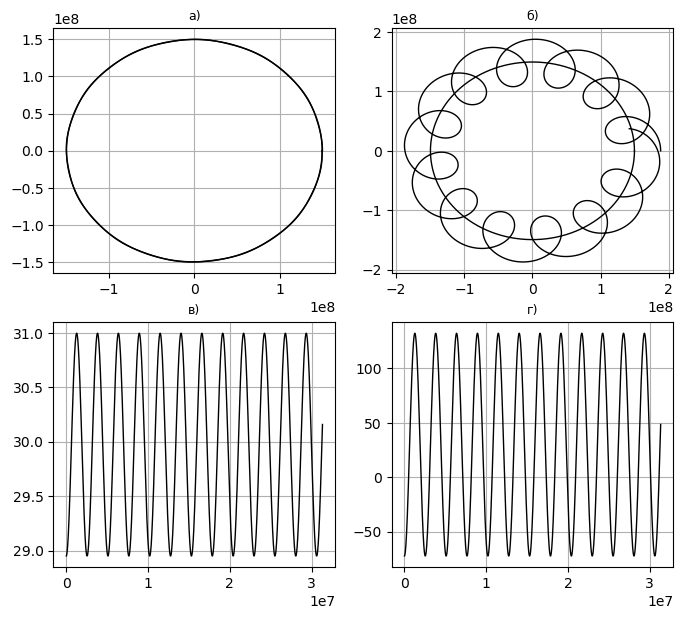

In [4]:
# Ячейка № 2

# задание радиуса орбиты Земли, км
R1 = 1.496 * 10**8

# задание периода обращения Земли вокруг Солнца, с
T1 = 3.136 * 10**7

# задание значений реального и
# гипотетического радиусов орбит Луны, км
R2_1 = 3.844 * 10**5
R2_2 = 3.844 * 10**7


# задание периода обращения Луны вокруг Земли, с
T2 = 2.360 * 10**6

# задание временной сетки, в узлах которой
# вычисляются значения координат Земли и Луны
t = np.arange(0, T1, T1 / 2000)

# определение шага используемой временной сетки
dt = t[2] - t[1]

# определение числа узлов используемой
# временной сетки
N = len(t)

# инициализация массивов, используемых для
# хранения абсцисс и ординат Земли
Xz = np.zeros(N)
Yz = np.zeros(N)

# инициализация массивов, используемых для
# хранения абсцисс и ординат Луны
Xm_1 = np.zeros(N)
Ym_1 = np.zeros(N)
Xm_2 = np.zeros(N)
Ym_2 = np.zeros(N)

# инициализация массивов, используемых для
# хранения абсцисс и ординат Земли
Xotn_1 = np.zeros(N)
Yotn_1 = np.zeros(N)
Xotn_2 = np.zeros(N)
Yotn_2 = np.zeros(N)

# вычисление координат орбиты Земли
Xz[:] = R1 * np.cos(2 * np.pi / T1 * t[:])
Yz[:] = R1 * np.sin(2 * np.pi / T1 * t[:])

# вычисление координат орбиты Луны
Xm_1[:] = R2_1 * np.cos(2 * np.pi / T2 * t[:])
Ym_1[:] = R2_1 * np.sin(2 * np.pi / T2 * t[:])
Xm_2[:] = R2_2 * np.cos(2 * np.pi / T2 * t[:])
Ym_2[:] = R2_2 * np.sin(2 * np.pi / T2 * t[:])

# вычисление координат орбиты Луны
# в гелиоцентрической системе координат
Xotn_1[:] = Xz[:] + Xm_1[:]
Yotn_1[:] = Yz[:] + Ym_1[:]
Xotn_2[:] = Xz[:] + Xm_2[:]
Yotn_2[:] = Yz[:] + Ym_2[:]

# вычисление мгновенных значений проекций
# линейной скорости Земли на координатные оси
Vx = np.diff(Xz) / dt
Vy = np.diff(Yz) / dt

# вычисление мгновенных значений проекций
# линейной скорости Луны на координатные оси
vx_1 = np.diff(Xm_1) / dt
vy_1 = np.diff(Ym_1) / dt
vx_2 = np.diff(Xm_2) / dt
vy_2 = np.diff(Ym_2) / dt

# вычисление значений узлов временной сетки,
# в узлах которой вычислены мгновенные значения
# проекций линейных скоростей Земли и Луны на
# координатные оси
Nd = len(Vx)
t1 = np.arange(0, T1 - dt, T1 / 2000)
V_1 = np.zeros(Nd)
V_2 = np.zeros(Nd)
V_1[:] = np.sqrt(Vx[:] ** 2 + Vy[:] ** 2) - (
    Vx[:] * vx_1[:] + Vy[:] * vy_1[:]
) / np.sqrt(Vx[:] ** 2 + Vy[:] ** 2)
V_2[:] = np.sqrt(Vx[:] ** 2 + Vy[:] ** 2) - (
    Vx[:] * vx_2[:] + Vy[:] * vy_2[:]
) / np.sqrt(Vx[:] ** 2 + Vy[:] ** 2)

# инициализация графического окна
fig = plt.figure(figsize=(8, 7))
ax = plt.subplot(2, 2, 1)

# визуализации орбиты Земли и Луны
# в гелиоцентрической системе координат
# для R2_1=3.844*10^5 км
plt.plot(Xotn_1, Yotn_1, "-k", lw=1)
plt.plot(Xz, Yz, "-k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация зависимости (1.7) для R2_1=3.844*10^5 км
ax = plt.subplot(2, 2, 3)
plt.plot(t1, V_1, "-k", lw=1)
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализации орбиты Земли и Луны
# в гелиоцентрической системе координат
# для R2_1=3.844*10^7 км
ax = plt.subplot(2, 2, 2)
plt.plot(Xz, Yz, "-k", lw=1)
plt.plot(Xotn_2, Yotn_2, "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация зависимости (1.7) для R2_1=3.844*10^7 км
ax = plt.subplot(2, 2, 4)
plt.plot(t1, V_2, "-k", lw=1)
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()
